<h3>Implementation of Neural Network from Sctrach</h3>


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.linear_model
import matplotlib

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10.0, 8.0)


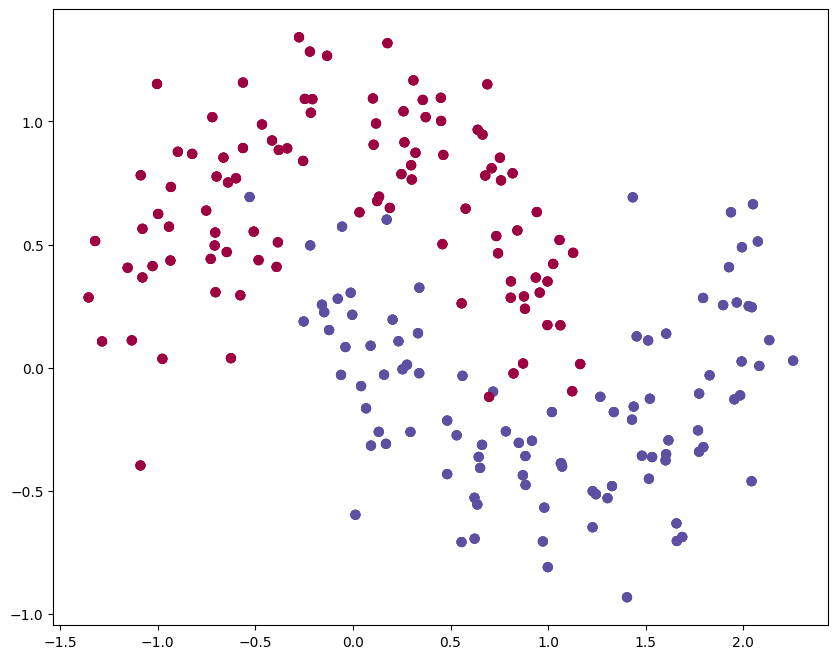

In [9]:
#generating dataset
np.random.seed(0)
X, y = sklearn.datasets.make_moons(200, noise=0.20)
                        # two half moon, 200 datapoints, noise to make messy
plt.scatter(X[:,0], X[:,1], s=40, c=y, cmap=plt.cm.Spectral)
#all x - coordinate  all y- coordinate
plt.show()

Red - Male
<br>
Blue - Female
<br>
we have to train a model that classifies them obviously non-linear and thing is neural netwrok will figure out it self we dont need to worry
<br>
input X and Y and output is 0 or 1 prediction of class

In [15]:
clf = sklearn.linear_model.LogisticRegressionCV(multi_class = 'ovr')
clf.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1955: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegressionCV(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [27]:
#now to plot descision boundaries 
"""
here we are plotting  a decision boundary 
prediction from every data points and check weather its 0 or 1 and then we plot a decsion boundary
"""
def plot_decision_boundary(pred_func):
   #finding max and min value of data set for plotting boundaries and adding some padding 
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + 0.5

    #creating a square grid
    h = 0.01 #gap between each grid step size = 0.01 thats high resulation
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h ))

    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    #np.c_ = combine grid into (x,y) pairs
    #xx.ravel(), yy.ravel() → grid ko flat list me convert

    #ploting decision boundaries
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:,1], c=y, cmap=plt.cm.Spectral)
    #this will fill region in colors for different class different colour

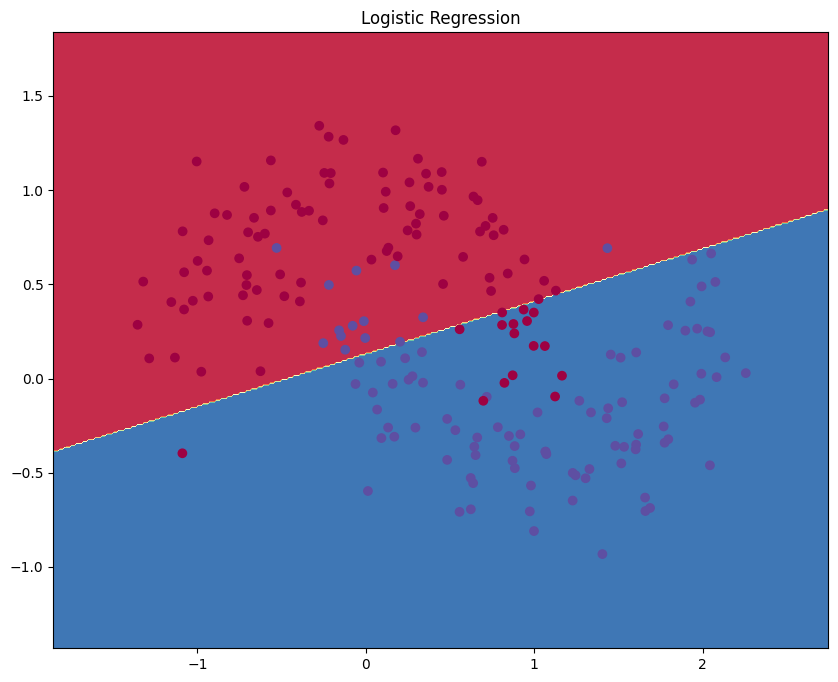

In [31]:
plot_decision_boundary(lambda x: clf.predict(x))
plt.title("Logistic Regression")
plt.show()

decision boundary by logistic regression in not enough 


<h3>Training a neural network </h3>

- 3 layer neural network
    - 1 input layer -  as x and y - 2 nodes
    - 2 hidden layer - for computation
    - 3 output layer - where 2 classes present - 2 nodes for male and female
- more no of nodes in hidden layer leads to more computational which will increase cost
- now activation function for hidden layer , 3 option
    - tanh - here we will use this
    - sigmoid function
    - ReLu
- and for output layer we will use `softmax` which is use for mutli classification and convert raw score into probability 

<h3>How netwrok make predictions </h3>

- Neural Network make prediction `forward propagation` which bunch of matrix mutiplication and an activation function
- output $\hat{y}$ is also in same dimension as 2D
-$$
\begin{aligned}
z_1 & = xW_1 + b_1 \\
a_1 & = \tanh(z_1) \\
z_2 & = a_1W_2 + b_2 \\
a_2 & = \hat{y} = \mathrm{softmax}(z_2)
\end{aligned}
$$

$z_1$ is input layer linear function that take x as input, from input to hidden layer 1 and then `a1 = tanh(z1)` then applying `tanh` activation function  in hidden layer and `a1` is output of hidden layer

<h3>Leraning Parameters</h3>

- we need to find right parameters that minimize the error on training data
- $W_1$, $b_1$, $W_2$, $b_2$
- loss function that measure error
- $$
\begin{aligned}
L(y,\hat{y}) = - \frac{1}{N} \sum_{n \in N} \sum_{i \in C} y_{n,i} \log\hat{y}_{n,i}
\end{aligned}
$$

Here we apply `cross entropy loss` that measures how wrong model's predicted probabilities are compare to actual answer
<br>
if model probability  is high less loss but probability is very less than high loss

to minimise the parameters we will use `gradient descent` and implement <b>batch gradient descent</b>

<h4>Gradient Descent</h4>

- to find parameters that does minimum loss gradient descent needs derivatie of Loss function wrt to parameters
- $\frac{\partial{L}}{\partial{W_1}}$, $\frac{\partial{L}}{\partial{b_1}}$, $\frac{\partial{L}}{\partial{W_2}}$, $\frac{\partial{L}}{\partial{b_2}}$.
- For calculating Gradient descent we will use `back propagation()` that start calculating from output 

## Forward Pass

$$
z_1 = W_1 x + b_1
$$

$$
a_1 = \sigma(z_1)
$$

$$
z_2 = W_2 a_1 + b_2
$$

$$
a_2 = \sigma(z_2)
$$

$$
L = \frac{1}{2}(a_2 - y)^2
$$

---

## Backpropagation

### Output Layer

$$
\frac{\partial L}{\partial W_2}
=
(a_2 - y) \cdot \sigma'(z_2) \cdot a_1^T
$$

$$
\frac{\partial L}{\partial b_2}
=
(a_2 - y) \cdot \sigma'(z_2)
$$

---

### Hidden Layer

$$
\frac{\partial L}{\partial W_1}
=
\left[(a_2 - y) \cdot \sigma'(z_2) \cdot W_2^T\right]
\cdot \sigma'(z_1) \cdot x^T
$$

$$
\frac{\partial L}{\partial b_1}
=
\left[(a_2 - y) \cdot \sigma'(z_2) \cdot W_2^T\right]
\cdot \sigma'(z_1)
$$

---

## Gradient Update

$$
W_1 = W_1 - \eta \frac{\partial L}{\partial W_1}
$$

$$
b_1 = b_1 - \eta \frac{\partial L}{\partial b_1}
$$

$$
W_2 = W_2 - \eta \frac{\partial L}{\partial W_2}
$$

$$
b_2 = b_2 - \eta \frac{\partial L}{\partial b_2}
$$

<h4>Implementation</h4>

In [82]:
num_examples = len(X) #training set size
nn_input_dim = 2# input layer dimension 
nn_output_dim = 2 #output layer dimension 

#gradient descent parameters
epsilon = 0.01 # its learning rate
reg_lambda = 0.01

In [104]:
#implementation of loss function that help us to evaluate our model
def calculate_loss(model):
    W1, b1, W2, b2 = model['W1'], model['b1'], model['W2'], model['b2']#defining weights
   
    #forward propagation will do  prediction
    z1 = X.dot(W1) + b1 #input to hidden layer 
    a1 = np.tanh(z1)#activation function
    z2 = a1.dot(W2) + b2 #hidden layer to output layer
    exp_score = np.exp(z2) #appllying softmax that gives probability scores for each data point
    probs = exp_score / np.sum(exp_score, axis=1, keepdims = True) #output of softmax

    #calulating the loss
    correct_logprobs = -np.log(probs[range(num_examples), y])
    data_loss = np.sum(correct_logprobs)

    #add regulatization term to loss
    data_loss += reg_lambda/2 * (np.sum(np.square(W1)) + np.sum(np.square(W2)))
    return 1/num_examples * data_loss

<h4>Explaination of above code</h4>
probs are output of softmax that are score for each data points<br>
two classes so we have [0.3, 0.9] 0.3 - male, 0.9 - female (basically probability)
<br>
then we choose 0.9 or correct one <br>
y - target values where correct class is already define so we can compute loss <br>

`log` use to punish model if score is close to 1 less loss and closer to 0 higher loss<br>
and then we sum loss of all data points as data_loss<br>



<h4>Regularization</h4>

- its penalty on large weights, it reduces the weights values that are not much important 
- model actually tries to memorize data points and leads to overfitting to prevent we use regularization


In [108]:
#helper function that predict output (0 or 1)
def predict(model, x):
    W1, b1, W2, b2 = model['W1'], model['b1'], model['W2'], model['b2']

#forward propagation
    z1 = x.dot(W1) + b1
    a1 = np.tanh(z1)
    z2 = a1.dot(W2) + b2
    exp_score = np.exp(z2)
    probs = exp_score / np.sum(exp_score, axis=1, keepdims=True)
    return np.argmax(probs, axis=1)

<h4>Building Model</h4>

In [123]:
#nn_hdim = no of nodes in the hidden layer
#num_passes = no of passes through the training data for gradient descent
#print_loss = print loss every 1000 iterations
def build_model(nn_hdim, num_passes=20000, print_loss=False):
    np.random.seed(0)
    #weight and bias initialization 
    W1 = np.random.randn(nn_input_dim, nn_hdim) / np.sqrt(nn_input_dim)
    b1 = np.zeros((1, nn_hdim))
    W2 = np.random.randn(nn_hdim, nn_output_dim) / np.sqrt(nn_hdim)
    b2 = np.zeros((1, nn_output_dim))

    model = {} #created a dictionary to get all learning parameters at the end
    
    #gradient descent
    for i in range(0, num_passes):
        #forward propagation
        z1 = X.dot(W1) + b1
        a1 = np.tanh(z1)
        z2 = a1.dot(W2) + b2
        exp_score = np.exp(z2)
        probs = exp_score / np.sum(exp_score, axis=1, keepdims=True)
        
        #backpropagation
        delta3 = probs #probs is output 
        delta3[range(num_examples), y] -= 1 # prediction - actual
        dW2 = (a1.T).dot(delta3)
        db2 = np.sum(delta3, axis=0, keepdims=True) #total error per neuron
        delta2 = delta3.dot(W2.T)*(1 - np.power(a1, 2))
                                #tanh derivation function dtanh(z)_dz = 1 - tanh^2(z)
        dW1 = np.dot(X.T, delta2)
        db1 = np.sum(delta2, axis=0)


        #adding regularization terms in W1  & W2
        dW2 += reg_lambda * W2
        dW1 += reg_lambda * W1

    #gradient descent parameters
        dW1 += -epsilon * dW1
        db1 += -epsilon * db1
        dW2 += -epsilon * dW2
        db2 += -epsilon * db2

    #now after finding parameters its time to add in model
        model ={'W1' : W1, 'b1' : b1, 'W2' : W2, 'b2' : b2}

        if print_loss and i % 1000 == 0:
          print("Loss after iteration %i: %f" %(i, calculate_loss(model)))

    return model
        

- when input pass through layer either its large or small both are bad for learning
- n inputs and divide by sqrt(n) this keeps <b>variance stable</b>
- without scaling -> <b>variance increases layer by layer</b>
- with scaling <b>variance stays in controlled</b>
- "*0.01" use in shallow networks where neural needs not to adaptive
- /sqrt(n) scale based on input size
- Variance - show how much data is spread
  

<h4>Back Propagation</h4>

- gradient start from output of the network here its probs`delta3 = probs`
- we find error in as prediction - actual
- dimension of a1 (N, hidden_size) initially -> a1.T -> (hidden_size, N)
- dW2 = (hidden_size, output_size) <=> `dW2 = (a1.T).dot(delta3)`
- weight depends on (input of layer * error of that layer )
- backpropagation moves backward from output layer to hidden to input layer
- delta2 goes to hidden layer and see how much it has contributed in error
- 

Loss after iteration 0: 0.583940
Loss after iteration 1000: 0.583940
Loss after iteration 2000: 0.583940
Loss after iteration 3000: 0.583940
Loss after iteration 4000: 0.583940
Loss after iteration 5000: 0.583940
Loss after iteration 6000: 0.583940
Loss after iteration 7000: 0.583940
Loss after iteration 8000: 0.583940
Loss after iteration 9000: 0.583940
Loss after iteration 10000: 0.583940
Loss after iteration 11000: 0.583940
Loss after iteration 12000: 0.583940
Loss after iteration 13000: 0.583940
Loss after iteration 14000: 0.583940
Loss after iteration 15000: 0.583940
Loss after iteration 16000: 0.583940
Loss after iteration 17000: 0.583940
Loss after iteration 18000: 0.583940
Loss after iteration 19000: 0.583940


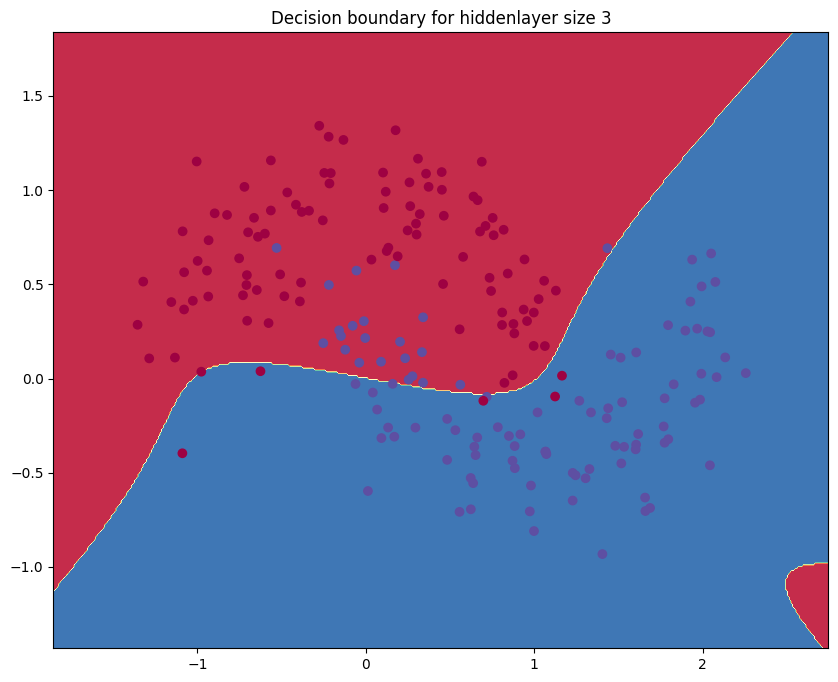

In [127]:
model = build_model(3,num_passes=20000, print_loss = True)
#this model has 3nodes hidden layer

plot_decision_boundary(lambda x: predict(model, x))
plt.title("Decision boundary for hiddenlayer size 3")
plt.show()

<h3>Varying the hidden layers</h3>
for 3 its same upto 20,000 iteration <br>
now for hidden size/nodes = 1, 2, 3, 4, 5, 20, 50 upto this

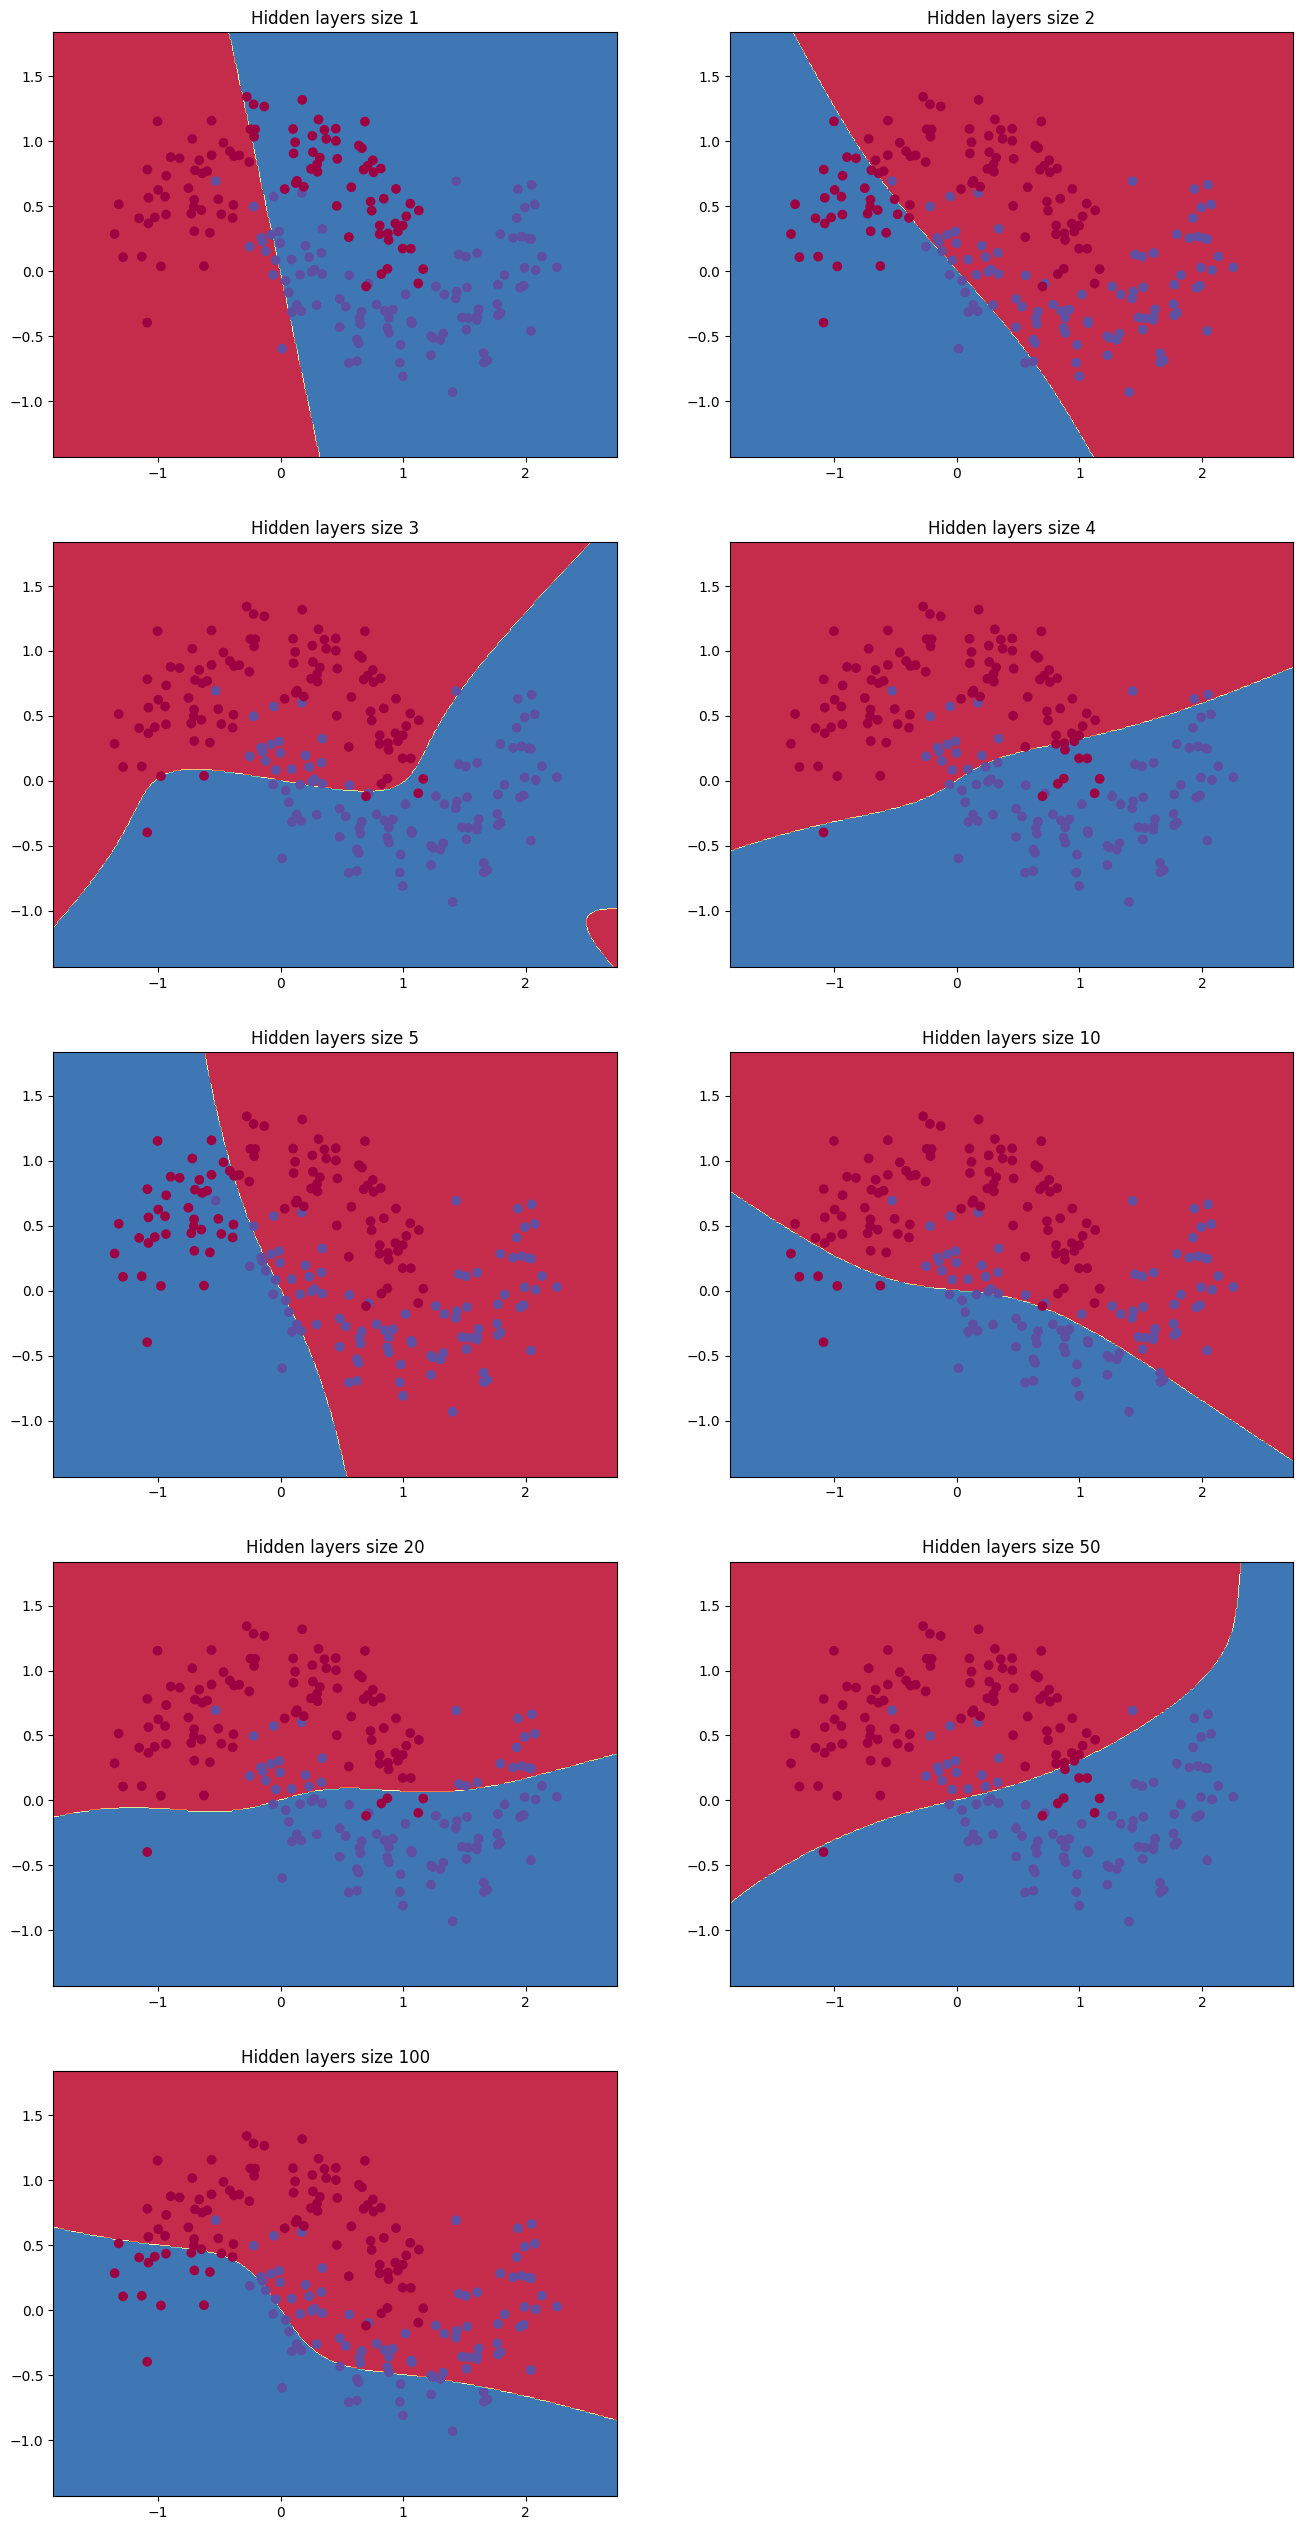

In [135]:
plt.figure(figsize=(16,32))
hidden_layer_dimensions = [1,2, 3, 4, 5, 10, 20 , 50, 100]

for i, nn_hdim in enumerate(hidden_layer_dimensions):
    plt.subplot(5, 2, i+1)
    plt.title("Hidden layers size %d" % nn_hdim)
    model = build_model(nn_hdim)
    plot_decision_boundary(lambda x: predict(model, x))
plt.show()